In [248]:
import pandas as pd
df=pd.read_csv('../scrape/combined_data.csv')

In [249]:
df.drop(['link', 'property_id', 'highlights','description'], axis=1, inplace=True)

In [250]:
from tabulate import tabulate
print(tabulate(df.head(),headers='keys',tablefmt='psql'))

+----+---------------------+--------------------------------------+---------------------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------+----------------------+-------------------+------------+-------------+-------------+-------------------+---------------------+---------------------------------------------------+------------------+----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [251]:
import regex as re
import numpy as np
def price(value):
    if isinstance(value,str):
        pattern=r'([\d.]+)\s*(Cr|Lac)'
        match=re.search(pattern,value)
        if match:
            number = float(match.group(1))
            if match.group(2)== 'Cr':
                return number * 1e7
            else :
                return number * 1e5
    return np.nan


In [252]:
def price_sqft(value):
    if isinstance(value,str):
        pattern = r'([\d,]+)\s*(/sqft|sqft)'
        match = re.search(pattern,value)
        if match:
            return int(match.group(1).replace(',',''))
    return value

In [253]:
#Extracted price and price per sqft
df['price']=df['price'].apply(price)
df['price_per_sqft']=df['price_per_sqft'].apply(price_sqft)
print(tabulate(df.head(),headers='keys',tablefmt='psql'))

+----+---------------------+--------------------------------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------+----------------------+-------------------+------------+-------------+-------------+-------------------+---------------------+---------------------------------------------------+------------------+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [254]:
def prop(value):
    if isinstance(value, str):
        # Combined regex to handle multiple patterns:
        pattern = (
            r'(?:BHK|Bedroom)\s+([\w\s]+?)\s+(?:for sale|in)'  # Group 1: Flat/House/etc.
            r'|'
            r'(Studio Apartments|[\d]+\s*RK\s*Flats)'          # Group 2: Studio or RK Flats
            r'|'
            r'/+\s*([\w\s]+)\s+in'                             # Group 3: Plot after "/"
        )
        
        match = re.search(pattern, value, flags=re.IGNORECASE)
        if match:
            # Only one of the groups will be filled
            for group in match.groups():
                if group:
                    return group.strip()
        return np.nan
    return np.nan


In [255]:
df['prop_type']=df['location'].apply(prop)
print(tabulate(df.sample(10),headers='keys',tablefmt='psql'))

+------+-------------------------------------------------+-----------------------------------------------------------+----------+------------------+-----------------------+---------------+----------------+------------+-----------------+-------------+-------------------+------------+-------------+------------+------------+---------------------+---------------------------------------------------+------------------+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [256]:
df['prop_type'].value_counts()

prop_type
Flat                         8415
House                        1441
Studio Apartments              91
Independent Builder Floor      79
Plot                           37
Farm house                      3
Serviced Apartment              2
Name: count, dtype: int64

In [257]:
#No of rooms extracted
def num_rooms(value):
    if isinstance(value,str):
        pattern = r'(\d|No)'
        match = re.search(pattern,value)
        if match:
            if match.group(1) == 'No':
                number = 0
                return int(number)
            else :
                return int(match.group(1))
    return np.nan

In [ ]:
df['bedrooms']=df['bedrooms'].apply(num_rooms)
df['bathrooms']=df['bathrooms'].apply(num_rooms)
df['balcony']=df['balcony'].apply(num_rooms)
print(tabulate(df.head(),headers='keys',tablefmt='psql'))

+----+---------------------+--------------------------------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------+----------------------+-------------------+------------+-------------+-----------+-------------------+---------------------+---------------------------------------------------+------------------+----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [259]:
def location(value):
    if isinstance(value,str):
        pattern = r'in\s+([\w\s]+,\s*[\w]+)'
        match = re.search(pattern,value)
        if match:
            return match.group(1)
        else:
            np.nan

In [260]:
df['location']=df['location'].apply(location)
print(tabulate(df.head(),headers='keys',tablefmt='psql'))

+----+---------------------+------------------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------+----------------------+-------------------+------------+-------------+-----------+-------------------+---------------------+---------------------------------------------------+------------------+----------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [261]:
def area(value):
    if isinstance(value,str):
        pattern = r',\s*([^,]+)$'
        match = re.search(pattern,value)
        if match:
            return match.group(1)
        else:
            return np.nan

def local_area(value):
    if isinstance(value,str):
        pattern=r'^(.*?),'
        match = re.search(pattern,value)
        if match:
            return match.group(1)
        else :
            return np.nan

df['city']=df['location'].apply(area)

df['location']=df['location'].apply(local_area)
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------+----------------------+-------------------+------------+-------------+-----------+-------------------+---------------------+---------------------------------------------------+------------------+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [262]:
def floor_num(value):
    if isinstance(value,str):
        pattern = r'(\d+)(?:st|nd|rd|th)'
        match = re.search(pattern,value)
        if match:
            if match.group(1)=='Ground':
                num=0
                return int(num)
            else:
                num=match.group(1)
                return int(num)
        else :
            return 0

df['floor']=df['floor'].apply(floor_num)
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------+----------------------+-------------------+------------+-------------+-----------+-------------------+---------+---------------------------------------------------+------------------+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [263]:
import ast
def ensure_list(x):
    if isinstance(x, str):
        return ast.literal_eval(x)  
    return x

# Convert both columns into actual lists
df['features'] = df['features'].apply(ensure_list)
df['features_list'] = df['features_list'].apply(ensure_list)

# Now replace empty features_list with features
df['features_list'] = df.apply(
    lambda row: row['features'] if len(row['features_list']) == 0 else row['features_list'],
    axis=1
)
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### Feature list Experiment

In [264]:
unique = set(item for sublist in df['features_list'] for item in sublist)
print(unique)
print(len(unique))

{'Lift(s)', 'Bank Attached Property', 'Recently Renovated', '24/7 Power Backup', 'Piped-gas', 'Rain Water Harvesting', 'Natural Light', 'High Ceiling Height', 'Maintenance Staff', 'Internet/wi-fi connectivity', 'Centrally Air Conditioned', 'Intercom Facility', '24/7 Water Supply', 'Swimming Pool', 'Water softening plant', 'Security / Fire Alarm', 'Separate entry for servant room', 'Fitness Centre / GYM', 'Low Density Society', 'False Ceiling Lighting', 'Waste Disposal', 'Car Parking', 'Feng Shui / Vaastu Compliant', 'Visitor Parking', 'Water purifier', 'Water Storage', 'Park', 'Club house / Community Center', 'Gymnasium', 'Airy Rooms', 'Club House', "Children's Play Area", 'Security Personnel', 'Shopping Centre', 'InterCom', 'Private Garden / Terrace', 'Power Back-up', 'Spacious Interiors', 'Fire Fighting Systems', 'No open drainage around'}
40


In [265]:
df['features_list'].isnull().sum()

np.int64(0)

In [266]:
df2=pd.DataFrame()
for i in unique:
    df2[i] = df['features_list'].apply(lambda x:int(i in x if isinstance(x,list) else False))
print(tabulate(df2.head(5),headers='keys',tablefmt='psql'))

+----+-----------+--------------------------+----------------------+---------------------+-------------+-------------------------+-----------------+-----------------------+---------------------+-------------------------------+-----------------------------+---------------------+---------------------+-----------------+-------------------------+-------------------------+-----------------------------------+------------------------+-----------------------+--------------------------+------------------+---------------+--------------------------------+-------------------+------------------+-----------------+--------+---------------------------------+-------------+--------------+--------------+------------------------+----------------------+-------------------+------------+----------------------------+-----------------+----------------------+-------------------------+---------------------------+
|    |   Lift(s) |   Bank Attached Property |   Recently Renovated |   24/7 Power Backup |   Piped-g

In [267]:
from sklearn.cluster import KMeans
wcss = []

# Calculate WCSS for cluster counts from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df2)
    wcss.append(kmeans.inertia_)

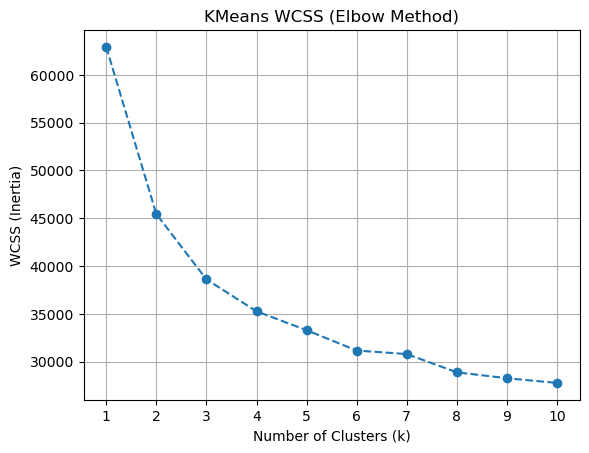

In [268]:
import matplotlib.pyplot as plt
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('KMeans WCSS (Elbow Method)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [269]:
feature_points = {
    # Essential value drivers (safety, power, water, parking)
    '24/7 Power Backup': 10,
    'Power Back-up': 10,  
    '24/7 Water Supply': 10,
    'Security Personnel': 9,
    'Car Parking': 9,
    'Visitor Parking': 8,
    'Fire Fighting Systems': 8,
    'Security / Fire Alarm': 8,
    
    # Lifestyle & Premium Amenities
    'Centrally Air Conditioned': 9,
    'Gymnasium': 8,
    'Fitness Centre / GYM': 8,
    'Swimming Pool': 8,
    'Club House': 7,
    'Club house / Community Center': 7,
    'Park': 7,
    "Children's Play Area": 7,
    'Private Garden / Terrace': 8,
    'Low Density Society': 8,
    'Recently Renovated': 7,
    
    # Comfort & Utility Features
    'Internet/wi-fi connectivity': 7,
    'Lift(s)': 8,
    'Rain Water Harvesting': 6,
    'Piped-gas': 6,
    'Water purifier': 6,
    'Maintenance Staff': 6,
    'Waste Disposal': 6,
    'Water Storage': 6,
    'Water softening plant': 6,
    'Spacious Interiors': 7,
    'Natural Light': 6,
    'Airy Rooms': 6,
    'High Ceiling Height': 6,
    
    # Decorative / Niche Features
    'False Ceiling Lighting': 4,
    'Separate entry for servant room': 4,
    'Intercom Facility': 5,
    'InterCom': 5,
    'Bank Attached Property': 4,
    'Shopping Centre': 5,
    'Feng Shui / Vaastu Compliant': 4,
    'No open drainage around': 5
}

def feature_map(value):
    return int(sum(feature_points.get(f,0) for f in value))

df['luxury_score'] = df['features_list'].apply(feature_map)
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### Rooms Feature Engineering (OHE)

In [270]:
rooms = set(i for i in df['others'])
print(rooms)
print(len(rooms))

{'Study Room,Pooja Room,Others', 'Servant Room,Others,Study Room,Pooja Room', 'Servant Room,Study Room', 'Pooja Room,Others,Study Room,Servant Room', 'Servant Room,Store Room,Pooja Room,Study Room', 'Others,Pooja Room,Servant Room,Store Room', 'Study Room,Others,Servant Room,Pooja Room', 'Others,Pooja Room,Study Room,Servant Room', 'Pooja Room,Study Room,Servant Room,Others', 'Study Room,Store Room,Servant Room', 'Pooja Room,Store Room', 'Pooja Room', 'Study Room,Store Room,Pooja Room', 'Pooja Room,Servant Room,Others,Study Room', 'Servant Room,Store Room,Study Room,Pooja Room', 'Servant Room,Store Room', 'Servant Room,Pooja Room,Store Room', 'Others,Store Room', 'Store Room,Study Room', 'Pooja Room,Servant Room,Study Room', 'Store Room,Pooja Room,Study Room', 'Servant Room,Others,Study Room', 'Store Room,Study Room,Pooja Room,Servant Room', 'Study Room,Servant Room', 'Study Room,Servant Room,Store Room,Pooja Room', nan, 'Study Room,Store Room,Servant Room,Pooja Room', 'Servant Room,St

In [271]:
def roomslist(value):
    if isinstance(value, str):
        # Split the string by commas and strip spaces
        return [v.strip() for v in value.split(',') ]
    return value
    
df['others'] = df['others'].apply(roomslist)
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [272]:
unique = set(i for sublist in df['others'] if isinstance(sublist,list) for i in sublist )
print(len(unique))
print(unique)

for room in unique:
    df[room] = df['others'].apply(lambda x: int(room in x if isinstance(x, list) else False))


5
{'Servant Room', 'Store Room', 'Pooja Room', 'Study Room', 'Others'}


In [273]:
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [274]:
# room_points = {
#     'Pooja Room': 4,
#     'Servant Room': 3,
#     'Study Room': 5,
#     'Store Room': 2,
#     'Others': 1
# }

# def room(value):
#     if isinstance(value,list):
#         return int(sum(room_points.get(v,0) for v in value))
    
# df['rooms'] = df['others'].apply(room)
# print(tabulate(df.head(),tablefmt='psql',headers='keys'))

#### Nearby location experiment

In [275]:
df['nearby_locations_list'] = df['nearby_locations_list'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

unique = set(v for sublist in df['nearby_locations_list'] if isinstance(sublist,list) for v in sublist)
print(len(unique))
print(unique)

8641
{'Omm Sai Nursing Home - Kandivali Mumbai', 'City Multispeciality', 'Aparc Attractions', 'Ambaji Dham', 'H.J. Doshi Ghatkopar Hindu Sabha Hospital', 'Billabong High International Schoo', "King's circle railway station", 'Vishwanath Hospital Mumbai', 'shivkrupa', 'Sai Samarth Clinic', 'Cross INRI', 'M V M’s College of Commerce and Science', 'Happy university', 'Malwani Fire Brigade', 'Kali Masjid', 'Thunga Hospital', 'Noble Plus', 'Bhaktivedanta Clinic', "Mani's Cafe", 'Gayatri Maternity and Ear Nose Throat Hospital', "Bobby's", 'Criti Care Hospital', 'Gokhale Road Municipal School', 'New Horizon Scholars School', 'Hira Mongi Navneet Hospital', 'Metropol Multispeciality Hospital', 'Balaji Restaurant', 'Apex Multispeciality Hospital', 'Shri Ram college of commerce and science', 'Karnavati Hospital Pvt. Ltd.', 'MG365', 'Thakur Village Road', 'R&R Eye Care Clinic', 'Life Panacea', 'City Centre Mall, SV Rd', 'Shah Lifeline Multispeciality Hospital', 'Vishwa Kripa Hospital', 'Kamerkar H

In [276]:
category_map = {

    # =========================
    # EDUCATION
    # =========================
    'school': 'School',
    'high school': 'School',
    'primary school': 'School',
    'international school': 'School',
    'vidyalaya': 'School',
    'vidyamandir': 'School',
    'college': 'College',
    'junior college': 'College',
    'degree college': 'College',
    'institute': 'Institute',
    'academy': 'Institute',
    'university': 'University',

    # =========================
    # HEALTHCARE
    # =========================
    'hospital': 'Hospital',
    'medical': 'Hospital',
    'medical centre': 'Hospital',
    'medical center': 'Hospital',
    'health care': 'Hospital',
    'healthcare': 'Hospital',
    'clinic': 'Clinic',
    'polyclinic': 'Clinic',
    'dispensary': 'Clinic',
    'maternity': 'Hospital',
    'nursing home': 'Hospital',
    'nicu': 'Hospital',
    'icu': 'Hospital',
    'diagnostic': 'Hospital',
    'eye': 'Speciality Hospital',
    'ent': 'Speciality Hospital',
    'cardiac': 'Speciality Hospital',
    'orthopaedic': 'Speciality Hospital',
    'urology': 'Speciality Hospital',
    'fertility': 'Speciality Hospital',
    'ivf': 'Speciality Hospital',
    'dental': 'Speciality Hospital',
    'children': 'Hospital',
    'critical care': 'Hospital',
    'trauma': 'Hospital',
    "pharmacy": "Healthcare",
    "care": "Healthcare",

    # =========================
    # TRANSPORT
    # =========================
    'railway station': 'Railway Station',
    'station': 'Railway Station',
    'rs': 'Railway Station',
    'metro': 'Metro Station',
    'metro station': 'Metro Station',
    'bus depot': 'Bus Stop',
    'bus stop': 'Bus Stop',
    'best depot': 'Bus Stop',
    'airport': 'Airport',
    'junction': 'Transport Hub',
    'highway': "Transport Hub",
    'express': "Transport Hub",
    'flyover': "Transport Hub",
    'road': "Transport Hub",
    'link road': "Transport Hub",

    # =========================
    # BANKING & FINANCE
    # =========================
    'bank': 'Bank',
    'atm': 'ATM',
    'co-op bank': 'Bank',
    'cooperative bank': 'Bank',

    # =========================
    # SHOPPING & COMMERCIAL
    # =========================
    'mall': 'Mall',
    'shopping mall': 'Mall',
    'market': 'Market',
    'bazaar': 'Market',
    'mart': 'Market',
    'dmart': 'Market',
    'plaza': 'Mall',
    'complex': 'Commercial Complex',
    'commercial': 'Commercial Complex',
    'business park': 'Commercial Complex',
    'it park': 'Commercial Complex',
    "tech park": "Commercial / Office",
    "corporate": "Commercial / Office",
    "campus": "Commercial / Office",
    "office": "Commercial / Office",

    # =========================
    # FOOD & HOSPITALITY
    # =========================
    'restaurant': 'Restaurant',
    'resto': 'Restaurant',
    'hotel': 'Hotel',
    'cafe': 'Cafe',
    'coffee': 'Cafe',
    'bar': 'Bar',
    'fast food': 'FastFood/Restaurant',
    'pizza': 'FastFood/Restaurant',
    'domino': 'FastFood/Restaurant',
    'mcdonald': 'FastFood/Restaurant',
    'biryani': 'FastFood/Restaurant',
    "dhaba": "Food & Beverage",
    "bistro": "Food & Beverage",
    "starbucks": "Food & Beverage",
    "burger": "Food & Beverage",
    "kfc": "Food & Beverage",
    "subway": "Food & Beverage",

    # =========================
    # RELIGIOUS
    # =========================
    'temple': 'Religious Place',
    'mandir': 'Religious Place',
    'church': 'Religious Place',
    'mosque': 'Religious Place',
    'masjid': 'Religious Place',
    'gurudwara': 'Religious Place',
    'dargah': 'Religious Place',
    "derasar": "Religious Place",

    # =========================
    # ENTERTAINMENT & LEISURE
    # =========================
    'cinema': 'Entertainment',
    'theatre': 'Entertainment',
    'movie': 'Entertainment',
    'stadium': 'Sports Facility',
    'sports': 'Sports Facility',
    'amphitheatre': 'Entertainment',
    'beach': 'Tourist Place',
    'park': 'Park',
    'garden': 'Park',
    'udyan': 'Park',
    "beach": "Tourist Place",
    "wadi": "Tourist Place",
    "water park": "Tourist Place",
    "amusement": "Tourist Place",

    # =========================
    # FUEL & UTILITIES
    # =========================
    'petrol pump': 'Fuel Station',
    'petroleum': 'Fuel Station',
    'hp petrol pump': 'Fuel Station',
    'bharat petroleum': 'Fuel Station',
    'indian oil': 'Fuel Station'
}


In [277]:
def normalize_location(name):
    name_lower = name.lower()
    for keyword, category in category_map.items():
        if keyword in name_lower:
            return category
    return 'Other'  # Anything that doesn’t match goes to 'Other'


In [278]:
# Normalize each list
df['nearby_locations'] = df['nearby_locations_list'].apply(
    lambda places: [normalize_location(p) for p in places] if isinstance(places, list) else []
)

In [279]:
print(tabulate(df['nearby_locations_list'].head(),tablefmt='psql'))

+---+--------------------------------+-----------------+---------------------------------+---------------------------------+------------------------------------------------------------------------+------------------------------------------+-------------------------------------+------------------------------------------------------+--------------------------------------+------------------------------------------------+---------------------------------------------------------+----------------------------------------------+--------------------------------------------------------+--------------------------------------------------+--------------------------------+-----------------------------------------------+-----------------------------------------------------+----------------------------------+----------------------------------------------------+-----------------------------+----------------------------------------+------------------------------------+------------------------+----------

In [281]:
df['normalized_categories'] = df['nearby_locations_list'].apply(
    lambda places: [normalize_location(p) for p in places]
    if isinstance(places, list) else []
)

In [282]:
category_counts = (
    df['normalized_categories']
    .explode()
    .value_counts()
)

category_counts_dict = category_counts.to_dict()
print(category_counts_dict)

{'Hospital': 89910, 'Other': 52461, 'Bank': 22942, 'Clinic': 20325, 'Railway Station': 16798, 'Religious Place': 15134, 'School': 12447, 'Speciality Hospital': 12039, 'FastFood/Restaurant': 4522, 'Cafe': 4414, 'Mall': 4354, 'Transport Hub': 3676, 'Hotel': 3669, 'College': 3317, 'Airport': 2980, 'Institute': 2642, 'Restaurant': 2457, 'ATM': 2212, 'Commercial Complex': 2064, 'Food & Beverage': 2040, 'Bar': 2037, 'Market': 2009, 'Entertainment': 1722, 'Sports Facility': 1722, 'Fuel Station': 1559, 'Park': 1509, 'Tourist Place': 1388, 'University': 1345, 'Bus Stop': 1282, 'Healthcare': 1174, 'Commercial / Office': 991, 'Metro Station': 421}


In [283]:
def extract_other_places(row):
    places = row['nearby_locations_list']
    cats = row['normalized_categories']

    if not isinstance(places, list) or not isinstance(cats, list):
        return []

    return [
        place
        for place, cat in zip(places, cats)
        if cat == 'Other'
    ]

df['other_places'] = df.apply(extract_other_places, axis=1)


In [284]:
all_other_places = (
    df['other_places']
    .explode()
    .dropna()
)

other_place_counts = all_other_places.value_counts().to_dict()

print(other_place_counts)

{'The Bombay Presidency Golf Club': 390, 'Chhatrapati Shivaji': 337, 'NH 48': 217, 'Golden Swan Country Club': 208, 'The Westin Mumbai Powai Lake': 188, 'ibis Mumbai Vikhroli': 186, 'Ghatkopar': 179, 'Raichura Prasuti Gruha': 176, 'Parvatibai Chavan Charitable Trust': 172, 'Sadguru': 172, 'Kokan Kinara': 165, 'Chaayos': 165, 'Mumbai Football Arena': 163, 'Jumbo King': 160, 'Nobel Chemist': 159, 'Sattva': 159, 'Timbuctoo Lounge': 157, "Pop Tate's": 157, 'Rajathani Seva Samiti': 157, 'Dr.Ronak Prakash Bhandari': 156, 'Samata Nagar': 156, 'Banana leaf': 155, 'Bhagwati Banquets': 154, 'IIT Bombay': 151, 'The J': 149, 'FRIENDS KATTA': 146, 'UFO revolving resturant': 146, 'Dr.Suresh C Anand': 144, 'Sankalp': 142, 'Peetuk': 142, 'Soda planet': 140, 'Ten One': 139, 'Dr Jayant Doshi': 139, 'Utsav': 138, 'Kitchen': 138, 'JP Morgan Chase': 136, 'Bid Detail': 134, 'Apollo': 133, 'Shubalaxmi': 131, 'Red Box': 131, 'Classic': 131, 'Riga chinese': 130, 'Pahadi Health Post': 127, 'Jai Mata Di Tea Stal

#### Continue

In [ ]:
df.drop(columns=['others','nearby_locations_list','furnish_details_list','gated_community'],inplace=True)
print(tabulate(df.head(),tablefmt='psql',headers='keys'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
def overlooking(value):
    if isinstance(value,str):
        return [v.strip() for v in value.split(',')]
    
df['overlooking'] = df['overlooking'].apply(overlooking)
print(tabulate(df.head(),tablefmt='psql',headers='keys'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
unique = set(v for sublist in df['overlooking'] if isinstance(sublist,list) for v in sublist)
print(len(unique))
print(unique)

6
{'Pool', 'Main Road', 'Park/Garden', 'Club', 'Sea facing', 'Others'}


In [ ]:
counts_dict = df['ownership'].value_counts().to_dict()
print(counts_dict)

{'Freehold': 6827, 'Co-operative Society': 2805, 'Leasehold': 336, 'Power of Attorney': 104}


In [ ]:
print(df['age'].value_counts().to_dict())

{'1 to 5 Year Old': 3651, '10+ Year Old': 2329, '0 to 1 Year Old': 1751, '5 to 10 Year Old': 1676, 'undefined': 353, 'Within 6 months': 71, 'Under Construction': 43, 'Within 3 months': 42, 'Immediate': 21, 'Dec 2026': 18, 'Dec 2025': 17, 'Jun 2026': 14, 'Dec 2027': 12, 'By 2025': 10, 'Oct 2026': 7, 'By 2026': 5, 'Mar 2026': 5, 'Jun 2027': 3, 'Jul 2026': 3, 'Dec 2028': 3, 'Sep 2028': 2, 'Dec 2029': 2, 'Jan 2026': 2, 'Mar 2028': 2, 'Jan 2032': 1, 'Mar 2029': 1, 'Nov 2027': 1, 'Mar 2027': 1, 'By 2030': 1, 'Jan 2027': 1, 'Apr 2026': 1, 'Aug 2026': 1, 'May 2026': 1, 'By 2028': 1, 'Oct 2027': 1, 'By 2027': 1, 'Nov 2026': 1, 'May 2028': 1, 'Sep 2027': 1, 'Jan 2029': 1}


In [ ]:
def ageing(value):
    if isinstance(value,str):
        pattern = r'([A-Za-z]{3,9}\s+\d{4})'
        match = re.search(pattern,value)
        if value.startswith('By') or value.startswith('Within') or value=='Under Construction':
            return 'Under Construction'
        
        elif match:
            return 'Under Construction'
        
        elif value=='0 to 1 Year Old':
            return "New"

        elif value == '1 to 5 Year Old':
            return "Relatively New"
        
        elif value == '5 to 10 Year Old':
            return "Relatively Old"
        
        elif value== '10+ Year Old':
            return "Old" 
        
        else :
            return 'Undefined'
        
df['ageing']=df['age'].apply(ageing)
print(tabulate(df.head(),tablefmt='psql',headers='keys'))

+----+---------------------+----------------+-----------+------------------+-----------------------+---------------+----------------+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
df.drop(columns=['features_list','features','rating_details','age','overlooking'],inplace=True)
print(df.shape)

(10114, 24)


In [ ]:
def loc(value):
    if isinstance(value, str):
        return re.sub(r'\s*(East|West)\b', '', value)
    return value

df['location']=df['location'].apply(loc)

In [ ]:
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+-------------+-----------+------------------+-----------------------+---------------+----------------+------------+----------------------+------------+-------------+-----------+---------+----------------+----------+-------------+--------+----------------+----------------+--------------+--------------+--------------+----------+----------------+
|    | property_name       | location    |     price |   price_per_sqft |   super_built_up_area |   carpet_area |   builtup_area | facing     | ownership            |   bedrooms |   bathrooms |   balcony |   floor | furnish_type   |   rating | prop_type   | city   |   luxury_score |   Servant Room |   Pooja Room |   Study Room |   Store Room |   Others | ageing         |
|----+---------------------+-------------+-----------+------------------+-----------------------+---------------+----------------+------------+----------------------+------------+-------------+-----------+---------+----------------+----------+---------

In [ ]:
df['city'].value_counts().to_dict()

{'Mumbai': 5640,
 'Thane': 1039,
 'Navi': 751,
 'Andheri': 296,
 'Malad': 281,
 'Kandivali': 268,
 'Chembur': 191,
 'Mira': 188,
 'Borivali': 177,
 'Goregaon': 118,
 'Mulund': 90,
 'Santacruz': 80,
 'Ghatkopar': 78,
 'Bhandup': 74,
 'Vikhroli': 64,
 'Chandivali': 53,
 'Dombivli': 50,
 'Kalyan': 48,
 'Jogeshwari': 43,
 'Dahisar': 42,
 'Kalamboli': 28,
 'Kurla': 28,
 'Virar': 28,
 'Raigad': 26,
 'Badlapur': 20,
 'Vile': 19,
 'Ulhasnagar': 19,
 'Parel': 18,
 'Dadar': 18,
 'Kanjurmarg': 17,
 'Bandra': 15,
 'Panvel': 13,
 'Sion': 12,
 'Powai': 10,
 'Ambernath': 10,
 'Malabar': 9,
 'Mumbra': 8,
 'Vidyavihar': 8,
 'Govandi': 7,
 'Khar': 7,
 'Marol': 7,
 'Nalasopara': 7,
 'Kalbadevi': 6,
 'Sakinaka': 6,
 'Bhayandar': 5,
 'Ghodbunder': 5,
 'Vasai': 5,
 'Kalwa': 5,
 'Seawoods': 5,
 'Manpada': 4,
 'Asalpha': 4,
 'Shivaji': 4,
 'Maharashtra': 4,
 'Girgaon': 4,
 'Titwala': 3,
 'Byculla': 3,
 'Bhiwandi': 3,
 'Mahim': 3,
 'Ulwe': 3,
 'Taloja': 3,
 'Umerkhadi': 3,
 'Sanpada': 2,
 'Mandvi': 2,
 'Cumbal

In [ ]:
mapping = {
    "Mumbai": [
        "Mumbai", "Andheri", "Malad", "Kandivali", "Chembur", "Borivali", "Goregaon",
        "Mulund", "Santacruz", "Ghatkopar", "Bhandup", "Vikhroli", "Chandivali",
        "Jogeshwari", "Dahisar", "Kurla", "Vile", "Parel", "Dadar", "Kanjurmarg",
        "Bandra", "Sion", "Powai", "Malabar", "Khar", "Vidyavihar", "Govandi",
        "Marol", "Sakinaka", "Kalbadevi", "Shivaji", "Girgaon", "Umerkhadi", "Mahim",
        "Byculla", "Worli", "Dharavi", "Prabhadevi", "Bhuleshwar", "Madh", "Fort",
        "Marine", "Matunga", "Mitha", "Mandvi", "Juhu", "Trombay", "IIT", "MIDC","Cumbala",
        "Lower", "Mankhurd", "New", "Anjur", "Ramabai", "Grant","Asalpha","Maharashtra",
        "Mira", "Naigaon", "Vasai", "Bhayandar", "Nalasopara", "Virar"
    ],
    
    "Thane": [
        "Thane", "Dombivli", "Kalyan", "Ulhasnagar", "Badlapur", "Mumbra",
        "Ambernath", "Ghodbunder", "Manpada", "Bhiwandi", "Titwala", "Kalwa",
        "Majiwada", "Palava"
    ],
    
    "Navi Mumbai": [
        "Navi", "Panvel", "Kalamboli", "Ulwe", "Seawoods", "Uran", "Sanpada",
        "Kharghar", "Airoli", "Belapur", "Nerul", "Neral", "Rasayani", "Vichumbe",
        "Damoji", "Shree","Taloja","Ghansoli"
    ]
}

reverse_city_mapping = {}
for city, areas in mapping.items():
    for area in areas:
        reverse_city_mapping[area.lower()] = city

df['city'] = df['city'].str.lower().map(reverse_city_mapping)


In [ ]:
df['city'].value_counts().to_dict()

{'Mumbai': 7973, 'Thane': 1216, 'Navi Mumbai': 820}

In [ ]:
df['city'].isna().sum()

np.int64(105)

In [ ]:
print(df.shape)
df = df.dropna(subset=["city"])
print(df.shape)

(10114, 24)
(10009, 24)


In [ ]:
df['prop_type'].value_counts().to_dict()

{'Flat': 8357,
 'House': 1399,
 'Studio Apartments': 91,
 'Independent Builder Floor': 78,
 'Plot': 34,
 'Farm house': 2,
 'Serviced Apartment': 2}

In [ ]:
df.loc[
    (df['prop_type'] == "Studio Apartments") | (df['prop_type'] == "Independent Builder Floor"),
    'prop_type'
] = "Flat"

In [ ]:
df = df[~df['prop_type'].isin(['Plot', 'Farm house', 'Serviced Apartment'])]
print(df.shape)

(9971, 24)


In [ ]:
df['prop_type'].value_counts().to_dict()

{'Flat': 8526, 'House': 1399}

In [ ]:
df['location'].value_counts().to_dict()

{'Kandivali': 423,
 'Chembur': 385,
 'Malad': 366,
 'Powai': 348,
 'Andheri': 322,
 'Goregaon': 320,
 'Mulund': 289,
 'Borivali': 284,
 'Ghatkopar': 220,
 'Wadala': 215,
 'Hiranandani Gardens Powai': 144,
 'Bhandup': 137,
 'Lokhandwala Kandivali': 129,
 'Santacruz': 119,
 'Thakur Village': 116,
 'Vile Parle': 115,
 'Chandivali': 110,
 'Mira Road': 106,
 'Virar': 103,
 'Dombivli': 103,
 'Worli': 99,
 'Karjat': 98,
 'Dahisar': 96,
 'Vikhroli': 88,
 'Kanjurmarg': 84,
 'Bandra': 81,
 'Hiranandani Estate': 77,
 'Kurla': 75,
 'Balkum': 71,
 'Kalyan': 70,
 'Marol': 69,
 'Parel': 68,
 'Byculla': 66,
 'Tilak nagar': 62,
 'Kharghar': 61,
 'Jogeshwari': 60,
 'Deonar': 59,
 'Panvel': 58,
 'Sher E Punjab Colony': 57,
 'Jankalyan Nagar': 56,
 'Juhu': 50,
 'Lower Parel': 49,
 'Kanjurmarg west': 49,
 'Khar': 49,
 'Evershine Nagar': 44,
 'Mahalaxmi': 42,
 'Dadar': 41,
 'Pokhran 2': 39,
 'Kolshet Road': 38,
 'Ulwe': 38,
 'Badlapur': 37,
 'Pant Nagar': 35,
 'Siddharth Nagar': 35,
 'Majiwada': 34,
 'Manpa

#### Location Standardizing

In [ ]:
mapping_area = {
    "Mira-Bhayandar": ["Mira Road", "Shanti Nagar", "Beverly Park", "Mahajan Wadi","mira road"],
    "Dahisar": ["Dahisar","Mandapeshwar", "Rawalpada","Kandarpada",
                "Shailendra Nagar", "Jaya Nagar", "Krishna Colony"],
    "Borivali": ["Borivali",
        "IC Colony", "Shimpoli", "Gorai", "Dahisar Check Naka", "Eksar",
        "Gorai 2", "Babhai", "Chikoowadi", "IC Colony Ext","Rajendra Nagar",
        "Vazira", "Gorai Nagar", "Gorai 3","Yogi Nagar","Sukarwadi"
    ],
    "Kandivali": ["Kandivali","Sai Nagar",
        "Thakur Village", "Lokhandwala Kandivali", "Mahavir Nagar", "Charkop","Babrekar Nagar",
        "Samata Nagar", "Magathane", "Asha Nagar", "Dahanukar Wadi",
        "Sector 5 Charkop", "Sector 6 Charkop", "Sector 3 Charkop", "Sector 8 Charkop",
        "Sector 2 Charkop", "Sector 4 Charkop", "Shankar Pada",
        "Samta Nagar", "Singh Agri Estate", "KANDIVALI WEST"
    ],
    "Malad": ["Malad",
        "Chincholi", "Evershine Nagar", "Jankalyan Nagar", "Orlem", "Marve",
        "Chincholi Bunder", "Dindoshi", "Bangur Nagar","Mahakali Caves",
        "Kurar Village", "Pathan Wadi", "malad west", "Parekh Nagar", "Sunder Nagar"
    ],
    
    "Goregaon": ["Goregaon", "Motilal Nagar 1", "Jawahar Nagar",
        "Film City Road", "Aarey Colony", "Vishveshwar Nagar", 
        "Aarey Milk Colony", "Yashodham", "Royal Palms",
        "goregaon east", "Best Nagar","Siddharth Nagar"
    ],
    "Andheri": ["Andheri", "JVLR",
        "Lokhandwala", "Versova", "Seven Bungalows", "Four Bungalows", "DN Nagar",
        "Veera Desai Road", "JB Nagar", "Poonam Nagar","Sakinaka", "Asalpha",
        "MIDC Chakala Industrial Area", "Gundavali Gaothan","Marol",
        "labh ashish chs andher", "Jp Road","Sher E Punjab Colony"
    ],
    
    "Juhu": ["Juhu", "Silver Beach", "Juhu Scheme","Juhu Tara", "Juhu Lane","Juhu Tara rd"],
    "Vile Parle": ["Vile Parle", "JVPD Scheme", "Jvpd Scheme"],
    "Santacruz": ["Santacruz", "Vakola", "Prabhat Colony", "Vakola Santacruz"],
    "Bandra": ["Bandra","Pali Village",
        "Bandra East", "Bandra West", "Kala Nagar", "Pali Hill"
    ],
    "Dadar": ["Dadar", "Dadar East", "Dadar West","Lokmanya Tilak Colony", "Shivaji Park", "Hindu Colony" ],
    "Wadala": ["Wadala", "Antop Hill"],
    "Worli": ["Worli", 
        "Prabhadevi", "Upper Worli", "Worli Naka",
        "Gandhi Nagar Worli", "Old Prabhadevi"
    ],
    "Parel":["Parel","Lower Parel","Mahalaxmi","Agar Bazar"],
    "Churchgate":["Sonapur"],
    "Kurla": ["Kurla", "Jagruti Nagar"],
    "Chembur": ["Chembur", 
        "Deonar", "Tilak Nagar", "Ghatla", "RCF Colony Chembur",
        "Collector Colony", "Chedda Nagar", "Swastik Park", "Deonar Municipal Colony",
        "Union Park", "Sindhi Society Chembur"
    ],
    "Ghatkopar": ["Ghatkopar", "Pant Nagar", "Garodia Nagar", "Barve Nagar",
                "Sainath Nagar","Maneklal Estate", "Amrut Nagar", "Ramabai Colony"],
    "Vikhroli": ["Vikhroli", 
        "Kannamwar Nagar 1", "Kannamwar Nagar 2", "Vikhroli Park Site", "Parksite Colony",
        "Hariyali", "Vikhroli Village"
    ],
    "Powai": ["Powai",
        "Hiranandani Gardens", "IIT", "Chandivali", "Tunga Village",
        "Panchkutir Ganesh Nagar", "Nahar Amrit Shakti", "Sangharsh Nagar",
        "Hiranandani Estate", "Raheja Vihar", "Lok Milan Colony"
    ],
    "Bhandup": ["Bhandup", "Jaydev Nagar", "Nahur", "Valmiki Nagar", "Battipada", "Jaydev Singh Nagar"],
    "Mulund": ["Mulund", "Gavanpada", "Jaihind Colony", "Deendayal Nagar",
        "Veena Nagar", "Nahur Gaothan", "Vardhman Nagar", "Gavane Pada Mulund"
    ],
    
    "Kanjurmarg": ["Kanjurmarg", "Kanjurmarg west"],
    "Vidyavihar": ["Vidyavihar", "Vidya Nagari","Kirol Village"],
    "Sion": [ "Sion", "GTB Nagar", "Pratikhsha Nagar"],
    "Mankhurd": ["Mankhurd", "Govandi"],
    "Thane": ["Thane", "Veer Savarkar Nagar", "Chatrapati Shivaji Nagar"
        "Panch Pakhadi", "Naupada", "Vasant Vihar", "Kopri", "Vartak Nagar",
        "Brahmand", "Kavesar", "Waghbil", "Dhokali", "Hiranandani Meadows",
        "Kapurbawadi", "Ambernath", "Kharegaon", "Datta Chowk","Kharvai",
        "Kasar vadavali","Ulhasnagar", "Manpada","Majiwada","Badlapur",
        "Kolshet Road","Pokhran 2","Balkum","Shahad", "Dahisar Mori"
    ],
    "Kalyan-Dombivli": ["Kalyan-Dombivli",
        "Thakurli", "Adharwadi", "Hanuman Nagar",
        "Ambernath", "Katemanivali", "Tukaram Nagar"
    ],
    "Mumbra": ["Kausa", "Mumbra"],
    "Diva": ["Diva"],   
    
    
    
    "Colaba": ["Colaba", "Cuffe Parade", "Nariman Point"],
    "Girgaon-Malabar": ["Girgaon", "Walkeshwar", "Malabar Hill", "Babulnath", "Chira Bazaar",
                 "Dhobi Talao", "Mohamed Ali Road", "Kumbharwada", "Cawasji Patel Tank","Gaiwadi", "Prathna Samaj"],
    "Grant Road": ["Grant Road"],
    "Agripada": ["Agripada", "Agripada", "Jacob Circle"],
    "Byculla": ["Byculla", "Madam Cama", "Chinchpokli", "Sane Guruji Nagar", "Umerkhadi", "Mustafa Bazar"],
    "Byculla-Mazgaon": ["Byculla-Mazgaon", "Sandhurst Road", "Lalbaug"],
    "Mazgaon-Chinchpokli": ["Mazgaon-Chinchpokli", "Mazgaon", "Chinchpokli"],
    "Mandvi-Bhuleshwar": ["Mandvi-Bhuleshwar", "Mandvi", "Bhuleshwar"],





    "Airoli": ["Airoli", "Sector 2 Airoli", "Sector 4 Airoli", "Sector 20B Airoli"],
    "Vashi": ["Vashi", "Sector 6 Vashi", "Sector 28 Vashi"],
    "Sanpada": ["Sanpada"],
    "Nerul": ["Nerul", 
        "Sector 17 Nerul", "Sector 27 Nerul", "Sector 21 Nerul", "Sector 28 Nerul",
        "Sector 19A Nerul", "Sector 18A Nerul"
    ],
    "Seawoods": ["Seawoods", "Sector 40 Seawoods"],
    "Belapur": ["Belapur", "Agroli","Sector 30 Belapur", "Sector 19 Belapur"],
    "Kharghar": ["Kharghar", 
        "Sector 35G Kharghar", "Sector 12 Kharghar", "Sector 35D Kharghar", "Sector 35I Kharghar",
        "Sector 34C Kharghar", "Sector 21 Kharghar", "Sector 19 Kharghar", "Sector 35E Kharghar",
        "Sector 23 Kharghar", "Sector 20 Kharghar", "Sector 15 Kharghar", "Sector 5 Kharghar",
        "Sector 7 Kharghar","Sector 6 Kharghar","Sector 34 Kharghar", "Sector 34A Kharghar", "Sector 34B Kharghar",
        "Sector 13 Kharghar", "Sector 10 Kharghar", "Sector 4 Kharghar",
        "Block G Sector 12 Kharghar", "Sector 18 Kharghar", "Sector 27 Kharghar"
    ],
    
    "Kamothe": ["Kamothe", "Sector 22 Kamothe", "Sector 21 Kamothe", "Sector 19 Kamothe", "Sector 18 Kamothe"],
    "Ulwe": ["Ulwe", "Sector 8 Ulwe", "Sector 5 Ulwe", "Sector 2 Ulwe", "Pushpak Nagar", "Sector 20 Ulwe", "Sector 16 Ulwe"],
    "Kalamboli": ["Kalamboli"],
    "Taloja": ["Taloja", "Taloja Panchanand", "Sector 24 Taloja"],
    "Roadpali": ["Roadpali", "Sector 17 Roadpali", "Sector 20 Roadpali"],
    "Panvel": ["Panvel", "Old Panvel", "Sector 6 New Panvel", "Sector 10 New Panvel"],
    "Sandhurst": ["Sandhurst", "Sandhurst Road"],
    
    
    
    
    
    "Others": ["Gandhi Nagar","Netaji Nagar","Shivaji Nagar",
        "Mumbai", "Friends Colony", "Jai Jawan Nagar", "Panchsheel Nagar",
        "Agashi", "Postal Colony", "Khalai Village", "Vadavali", "Khardi", "Boisar",
        "Industrial Area", "Hallow Pul", "Karve Nagar", "Paranjape Nagar", "Mahesh Nagar", "Link Road",
        "Sen Nagar", "Chandan Shanti", "Vithal Nagar", "Miragaon", "Kamlakar Nagar",
        "Phoolpada Road", "Gamdevi", "Kevni Pada", "Phase 7 Geeta Nagar", "Sriprastha",
        "Kemps corner", "Navghar", "Rayani Gram", "Ghodapdeo", "Yamuna Nagar",
        "Jai Hind Nagar", "Tanji Nagar", "Neral matheran", "Lal Bahadur Shastri Nagar",
        "Jijamata Colony", "Sriprastha", "Mbh Colony", "Jagjivan Ram Nagar", "Pereira Wadi",
        "Potohar Nagar", "New Link Road", "Save Nagar", "Babulnath",
        "Shanti Vihar", "Umershetpada", "Maratha Colony",
        "sunny road", "DGQA Colony", "Brahmanwadi", "Mahatma Jyotiba Phule Nagar",
        "share punjab", "Sathi D Souza Nagar", "Mohananad Nagar",
        "Dhaku Prabhuchi Wadi", "Navy Colony", "Halav Pool", "Meghwadi", "Dina Bama Estate",
        "Vishwakarma Nagar", "Mahalaxmi Sindhi Colony", "Unique Gardens", "Kunchi Kurve Nagar",
        "Gaurishankar Wadi", "Saraswati Baug", "Masjid Bandar", "Shree Ram Nagar",
        "coral", "Neelkanthnagar", "Asavari", "Sabale Nagar", "RBI Staff Colony",
        "Dattaguru Nagar", "Kanjur Village", "Nensey Colony", "Bhadwad", "Nandkar",
        "407"
    ]
}


In [ ]:
mapping_area.keys()

dict_keys(['Mira-Bhayandar', 'Dahisar', 'Borivali', 'Kandivali', 'Malad', 'Goregaon', 'Andheri', 'Juhu', 'Vile Parle', 'Santacruz', 'Bandra', 'Dadar', 'Wadala', 'Worli', 'Parel', 'Churchgate', 'Kurla', 'Chembur', 'Ghatkopar', 'Vikhroli', 'Powai', 'Bhandup', 'Mulund', 'Kanjurmarg', 'Vidyavihar', 'Sion', 'Mankhurd', 'Thane', 'Kalyan-Dombivli', 'Mumbra', 'Diva', 'Colaba', 'Girgaon-Malabar', 'Grant Road', 'Agripada', 'Byculla', 'Byculla-Mazgaon', 'Mazgaon-Chinchpokli', 'Mandvi-Bhuleshwar', 'Airoli', 'Vashi', 'Sanpada', 'Nerul', 'Seawoods', 'Belapur', 'Kharghar', 'Kamothe', 'Ulwe', 'Kalamboli', 'Taloja', 'Roadpali', 'Panvel', 'Sandhurst', 'Others'])

In [ ]:
mapping_area.update({
    "Vasai-Virar": ["Vasai-Virar","nallasopara",'Virar', "virar east", "nalasopara east", "Dongarpada", "Pelhar", 
            "Baneli", "Chinch Aali", "Joveli Gaon","Vasai","Kanchpada","Naigaon", "Nalasopara", "Uttan",
            "virar west", "HDIL layout chikaldongari virar west"],
    "Mira-Bhayandar": mapping_area["Mira-Bhayandar"] + ["Kashimira","Bhayandar",
        "Shyam Nagar", "Naya Nagar", "Beverly Park", "Mithchowki",
        "Near GCC Club", "Poonam Sagar Complex", "Kashigaon", "Medetiya Nagar"],
    "Borivali": mapping_area["Borivali"] + [
        "Gorai 1", "Yashavant Nagar", "Haridas Nagar", "Ramgad Nagar", "Dongripada",
        "Star Colony", "Kamathi Wada", "Gavraipada", "Bhimnagar",
        "Navapada", "Rambaug", "Dattani Nagar", "Samrat Ashok Nagar","Churi Wadi"
    ],
    "Kandivali": mapping_area["Kandivali"] + [ "Sector 7 Kandivali", "Sector 9 Charkop", "Akurli Nagar", "Ashok Nagar Kandivali", 
        "Pai Nagar", "Pushpa Park", "Unnat Nagar", "Unnat Nagar 2", "Kanakia Park", "Kanakiya", "Kulupwadi", "Kandivali west",
        "Motilal Nagar 3", "Loknagari","Thakur complex","Sector 1 Charkop" ],

    "Malad": mapping_area["Malad"] + [
        "Irani Wadi", "Liberty Garden", "Mitha Nagar", "Rathodi", "Malpa Dongri", "Shankarwadi",
        "Kharodi Naka", "Chinchodyacha Pada","Marve Village", "Milat Nagar", "Phase 4 Jankalyan Nagar",
        "Azad Nagar", "Malvani", "Mindspace", "Kastur Park", "Marve Road"
    ],
    "Goregaon": mapping_area["Goregaon"] + ["Suchi Dham", "Swami Samarth Nagar", "Pimpripada","Nadiyawala Colony 2",
                                            "Gokuldham Colony"],
    "Jogeshwari":["Oshiwara","Behram Baug","Natwar Nagar", "Jogeshwari"],
    "Andheri": mapping_area["Andheri"] + [
        "Aram Nagar", "Aram Nagar Part 1", "Versova Village", "Irla", "Chuim Village",
        "Andheri kamala co operative housing society off j p road opp Navrang Cinema",
        "Kondivita", "Sahar", "Nl Complex", "Lokhandwala Andheri", "Amboli", "Anand Nagar", "Chakala",
        "Ashok Nagar", "Yari Road"
    ],
    "Santacruz": mapping_area["Santacruz"] + ["Shivaji nagar Vakola", "Kolivery Village","SV Road","Shivaji Nagar","Kalina"],
    "Bandra": mapping_area["Bandra"] + ["Band Stand", "Reclamation","Bandra Kurla Complex", "Seven Bunglow"],
    "Dadar": mapping_area["Dadar"] + [
        "Saraswat Colony", "Century Bazaar", "Bhawani Sankar"
    ],
    "Khar": ["Ram Krishna Nagar","Khar"],
    "Mahim":["Mahim"],
    "Worli": mapping_area["Worli"] + [
        "BDD Chawls Worli", "Senapati Bapat Marg", "Delisle road", "Century Bazaar",
        "Mahalaxmi Railway Station", "Haji Ali"
    ],
    "Matunga":["Joshi vadi", "Matunga"],
    "Kurla": mapping_area["Kurla"] + ["nerul nagar kurla east", "Qureshi Nagar", "Netaji Subhash Nagar","Mata Ramabai Ambedkar Nagar", "Lallubhai Compound"],

    "Chembur": mapping_area["Chembur"] + [
        "Baiganwadi", "Chembur Gaothan", "Borla", "Barve Nagar", "RCF BARC Colony", "Bhakti Park","Pestom Sagar Colony"
    ],
    "Ghatkopar": mapping_area["Ghatkopar"] + [
        "Rajawadi Colony", "Pant Nagar", "Ramabai Ambedkar Nagar"
    ],
    "Vikhroli": mapping_area["Vikhroli"] + ["Tagore Nagar", "Ekvira Darshan","Nehru Nagar"],
    "Powai": mapping_area["Powai"] + ["IIT Area",'Hiranandani Gardens Powai',"BMC Colony"],
    "Bhandup": mapping_area["Bhandup"] + ["Sheshwadi", "Tulshetpada","Gavane Pada", "Datar Colony"],
    "Mulund": mapping_area["Mulund"] + ["Vatsalabai Naik Nagar", "Vasant Oscar", "Akurli","Khindipada","Mulund Colony"],
    "Sion": mapping_area["Sion"] + ["Sion Trombay Road", "Sion Koliwada"],
    "Mankhurd": mapping_area["Mankhurd"] + ["Trombay", "Mysore Colony"], 
    "Khanda Colony": ["Khanda Colony", "Sector 4A Khanda Colony", "Sector 5 Khanda Colony", "Greater Khanda", "Sector 11 Khanda Colony",
                      "Sector 17 Khanda Colony"],

    "Thane": mapping_area["Thane"] + ["Uthalsar", "Gawand Baug", "Louis Wadi", "Balkum Naka", "Dhokali", "Goddev Village", 
                                      "khopat", "Kolshet", "Kolbad", "Yogidham", "Gaodevi","Gundavali", "Titwala", "Ghodbunder Road", "Khadakpada", "Pokharan Road",
                "Shastri Nagar", "Shastri Nagar ", "Chikhal Dongari", "Laxmi Nagar","Pirojshanagar", "Daulat Nagar", "Dattapada", "Upper Govind Nagar",
        "Mhada Colony", "Madh", "Shilphata", "Adarsh Nagar", "Hatkesh Udhog Nagar","Moti Nagar", "Kalwa", "Shahapur", "SV Patel Nagar", "Ambedkar Nagar",
        "Subhash Nagar", "Chirag Nagar", "Anjurdive", "Ramdev Park", "Alika Nagar","Gangawadi", "Kasam Baug", "Lal Baug", "Tambe Nagar", "Gaon Devi",
        "Bhatwadi", "Savarkar Nagar", "Bhadran Nagar", "Nirmal Nagar", "Devipada","Ganesh Nagar", "Navagaon", "LIC Colony", "Vinay Nagar", "Vaishali Nagar",
        "Hanuman Chowk", "Chanakya Nagar", "Somwari Bazar", "Tata Colony","Yashwant Nagar", "Teen Hath Naka", "Tembhipada", "Mahadeo Wadi","Pratap Nagar"],

    "Kalyan-Dombivli": mapping_area["Kalyan-Dombivli"] + ["Dombivli",
        "Beturkar Pada", "Katrap", "Sagaon", "Wayle Nagar", "Tisgaon", "Hendre Pada",
        "Varap", "Ambika Nagar", "Nilje Gaon", "Manda", "Nevali", "Charai", "Godrej hill",
        "Kachore Gaon", "Vithalwadi", "Rambaug", "Dombivli Manpada", "Kulgaon", "Shiv Shakti Nagar",
        "Ambivli", "KALYAN Bhiwandi BYPAS", "Kolsewadi", "Dwarli Pada", "Dawadi Gaon",
        "Ayodhya Nagari", "Dhakate Shahad", "Annapurna Nagar",
        "Dahivali", "Mariam Nagar", "Kopar", "Usarghar Gaon",
        "dombivli west", "KALYAN Bhiwandi BYPASS"
    ],
    "Mumbra": mapping_area["Mumbra"] + ["Mumbra Station"],
    "Bhiwandi": ["Bhiwandi", "Mankoli", "Narpoli"],
    "Karjat":["Karjat"],




    "Colaba": mapping_area["Colaba"] + ["Colaba", "Cumbala Hill", "Peddar Road", "Breach Candy"],
    "Girgaon":# mapping_area["Girgaon"] +
      [
        "Thakurdwar", "Dongri", "Marine Lines", "Marine Drive", "Napean Sea Road"
    ],
    "Mazgaon": #mapping_area["Mazgaon"] + 
    ["Dongri", "Chinchbunder"],
    "Byculla": mapping_area["Byculla"] + ["Nagpada", "Kamathipura", "Reay Road","Tardeo","Sewri"],

    "Cumbala Hill": ["Cumbala Hill", "Peddar Road", "Cumbala Hill", "Breach Candy"],    
    



    "Airoli": mapping_area["Airoli"] + ["Sector 6 Airoli", "Sector 2B Airoli", "Sector 8A Airoli", "Sector 8 Airoli", "Sector 20 Airoli", "Sector 19 Airoli",
        "Sector 9 Airoli", "Sector 16 Airoli"],
    "Ghansoli": ["Ghansoli","Sector 30 Ghansoli", "Sector 16 Ghansoli","Sector 4 Ghansoli", "Sector 21 Ghansoli", "Sector 15 Ghansoli",
        "Sector 11 Ghansoli", "Sector 23 Ghansoli", "Sector 2 Ghansoli"],
    "Vashi": mapping_area["Vashi"] + [
        "Sector 29 Vashi", "Sector 12 Vashi", "Sector 7 Vashi", "Sector 14 Vashi",
        "Sector 4 Vashi", "Sector 10 Vashi", "Sector 16 Vashi", "Sector 8 Vashi", "Sector 10A Vashi","Sector 16 Vashi (dup)", 
        "Sector 8 Vashi (dup)", "Sector 4 Vashi (dup)", "Sector 6 Vashi (dup)", "Sector 28 Vashi (dup)", "Sector 10 Vashi (dup)"
    ],
    "Sanpada": mapping_area["Sanpada"] + ["Sector 4 Sanpada","Sector 5 Sanpada"],
    "Nerul": mapping_area["Nerul"] + ["Sector 9 Nerul", "Sector 23 Nerul", "Sector 10 Nerul","Sector 16 Nerul", "Sector 16A Nerul",
                                       "Sector 18 Nerul", "Sector 19 Nerul", "Sector 29 Nerul", "Sector 1 Shiravane"],
    "Seawoods": mapping_area["Seawoods"] + ["Sector 58 Seawoods", "Sector 50 Seawoods", "Sector 42 Seawoods", "Nerul Seawoods Sector 40"],
    "Belapur": mapping_area["Belapur"] + ["Sector 15 Belapur", "Sector 29 Belapur"],
    "Kamothe": mapping_area["Kamothe"] + [
        "Sector 15 Kamothe", "Sector 20 Kamothe", "Sector 36 Kamothe", "Sector 11 Kamothe",
        "Sector 17 Kamothe", "Sector 24 Kamothe", "Sector 10 Kamothe",
        "Sector 34 Kamothe", "Sector 9 Kamothe","Sector 35 Kamothe"
    ],
    "Ulwe": mapping_area["Ulwe"] + ["Sector 21 Ulwe", "Sector 23 Ulwe", "Sector 3 Ulwe", "Sector 19B Ulwe", "Sector 19 Ulwe",
                            "Sector 9 Ulwe", "Sector 17 Ulwe", "Sector 18 Ulwe"],
    "Kalamboli": mapping_area["Kalamboli"] + ["Sector 8 Kalamboli"],
    "Taloja": mapping_area["Taloja"] + ["Sector 20 Taloja", "Sector 26 Taloja Phase 2", "Taloja Phase 2", "Sector 37 Taloja", "Sector 16 Taloja"],
    "Panvel": mapping_area["Panvel"] + [
        "Sector 5 New Panvel", "Sector 3 New Panvel", "Sector 11 New Panvel", "Sector 13 New Panvel", "new panvel",
        "Taloja Phase 1", "Taloja Phase 2", "Navade", "Sukapur", "Panvel", "Devad", "Cidco Colony", "Pushpak Nagar",
        "Sector 12 New Panvel", "Palaspe Phata"
    ],
    "Turbhe": ["Turbhe", "Turbhe MIDC"],
    "Navi Mumbai":["Kopar Khairane", "Vichumbe", "Sector 25 Khandeshhwar"],




    
    "Mumbai":["Dharavi","Chunabhatti","Tirupati Nagar Phase 2", "Shivai Nagar", "Golibar", "Kapadia Nagar",
        "Air Force Quarters", "Sag Baug", "Mohili", "Kherwadi", "Bhoiwada", "Opera House",
        "Nadiyawala Colony 1", "Ashok Van", "Adarsh Dugdhalaya", "New Rajaram Wadi",
        "Parmanand Wadi", "Abhyudaya Nagar", "Jethava Nagar", "Kajupada",
        "Siddheshwar Nagar", "Ram Nagar", "Parbat Nagar", "Chikuwadi",
        "Mohite Wadi", "Vijaykar Wadi", "Bhavani Nagar", "Santosh Nagar",
        "Anita Nagar", "Motilal Nagar 2", "Kamgar Nagar", "Devripada",
        "Garibachawada", "Kadamwadi", "Poonam Gardens", "Buwapada",
        "MIDC Residential Area", "Sardar Vallabhbhai Patel Nagar", "Tolaram Colony",
        "Kranti Nagar", "Phase 2", "Ekta Nagar", "Gaikwad Nagar", "MIDC",
        "Mumbai Nashik Highway", "Govardhan Nagar", "Ghartan Pada", "Kailash Colony",
        "Jay Prakash Nagar", "Kolshet Industrial Area", "Gautam Nagar", "Piramal Nagar",
        "Kailash Nagar", "Kamala Nagar", "Sanjay Nagar", "Narayan Nagar",
        "Jari Mari", "Khira Nagar", "Saki Vihar", "JK Gram", "Parsi Wada",
        "Parshiwadi Varachi", "Lokmanya Nagar", "Harbadevi", "Ratan Nagar",
        "Chittranjan Nagar", "Divya Park", "BARC", "Kharodi Village", "Bafhira Nagar",
        "Manisha nagar", "Hari Om Nagar", "Khadavali", "Desale Pada", "Rajawadi",
        "Fish Market Area", "Pathan Colony", "Khetwadi", "Sagar City",
        "Narayan Nagar Ghatkopar west", "Sector 3 Shanti Nagar", "Gulmohar Colony",
        "Juni", "Samel Pada", "Panchamratna Park", "Shirdi Nagar", "Sunil Nagar"],
    "Others": mapping_area["Others"] + [
        "Asangaon", "Dronagiri", "Bolinj", "Owale", "Kasheli", "Pranay Nagar", "Vishnu Nagar", "Parsik Nagar ",
        "Navneeth Colony", "Hira Nagar", "Indralok Phase 6", "Vivekanand Nagar", "Adai", "Sopara", "Sidhi Vinayak Nagar",
        "Kegaon", "Naka", "Parsi Colony", "Petali", "Kongaon", "Karade Khurd", "Vasind", "Ushma Nagar", "Bhaskar Colony",
        "Gaondevi Dongri", "Maharashtra Nagar", "Naidu Colony", "Bhayandarpada", "Patlipada", "Rajiv Gandhi Nagar",
        "Govind Nagar", "Neelam Nagar", "Sindhu Wadi", "Khar Kopar", "Khatiwali", "Jambhulpada", "Ambivali", "Wagholi",
        "Mothagaon", "Sonivali", "lonavala", "Casa Bella", "Chinchoti", "Palm Beach", "HMPL Surya Nagar", "Padma Nagar",
        "Sadan wadi", "Yashaswi Nagar", "Shirgaon", "Sarvodaya Nagar", "Sambhaji Nagar", "Mira Gaothan", "Lamington Road",
        "Ajit Nagar", "Siddharath Nagar", "New Mhada Society", "Kokan Nagar", "Kanakiya", "Mamletdar Wadi", "Bharat Nagar",
        "Meghdoot", "Brahmanwada", "Sindhu Nagar", "Shri Nagar", "Savitribai Phule Nagar", "Dev Nagar", "Vijay Nagar",
        "Kumud Nagar", "Golani Naka", "Nilemore", "CST", "Laxman Nagar", "Gandhar Nagar", "Sonar Pada", "Naringi",
        "Shidivinayak Colony", "Jijamata Nagar", "Shaninagar", "Indira Nagar", "Savoli", "Ganga Vihar", "Sagarli",
        "Krishna Park", "Muthaval", "Mirashi Nagar", "kalyan", "Bhagat Colony", "Khoni",
        "Sindhu Cementers Tavisa", "Old Zakat Naka", "Panjarpole", "Hind Nagar", "Shahabaj", "on request", "Waliv",
        "Papdi", "Mukund Nagar", "bhakti homes", "Arya Nagar", "Mulgaon", "Vajreshwari", "Jui", "Swanand Nagar",
        "Shailesh Nagar", "Katai Naka", "Jawsaigaon", "Dhobi Ali", "lakhander", "Ambadi Naka", "Inamdar Wada",
        "Arunoday Nagar", "Dhuru Wadi", "Fisherman colony", "Ambewadi", "Murdha", "Mahapoli", "Manera Gaon",
        "107 anandnagar", "Potgaon", "Adaigaon", "Wadeghar", "Sai Gaon", "Dionna", "Manohar Nagar", "Vithaldas Nagar",
        "Dawood Baug", "Nav Indraprastha CHS", "MMRDA Area", "Aptewadi", "Nav Pada", "Nane Pada", "Jai Ambe Nagar",
        "Barrister Nath Pai Nagar", "Chandrakant Dhuru Wadi", "nilemore nallasa", "Vijay Park", "Safed Pul", "VSNL Colony",
        "Suresh Nagar", "Dhakoji Sethpada", "New Gautam Nagar", "Shantivan", "Sindhi Colony", "Central Area",
        "Khandelwal Layout", "Mangal Nagar", "Xo chs", "Ghotkamp Koyana Vele", "luna wala", "Waliv Phata", "Pawan Baug",
        "Sector 14 Kalamboli", "Juhu Circle", "OT Section", "lurbanum road",
        "Yagna Nagar", "Anand Koliwada", "Maratha Section 32", "Saraswat Nagar", "Surai", "Amar Nagar", "Housing Board Colony",
        "Chinchpada Gaon", "Wahal", "Midc Colony", "Khardev Nagar", "Bhivpuri"
    ]
})


In [ ]:
reverse_loc_mapping = {}
for loc, areas in mapping_area.items():
    for area in areas:
        reverse_loc_mapping[area.lower()] = loc

df['location_area'] = df['location'].str.lower().map(reverse_loc_mapping)

In [ ]:
len(df['location_area'].value_counts().to_dict())

69

#### Continue

In [ ]:
print(tabulate(df.head(5),headers='keys',tablefmt='psql'))

+----+---------------------+-------------+-----------+------------------+-----------------------+---------------+----------------+------------+----------------------+------------+-------------+-----------+---------+----------------+----------+-------------+--------+----------------+----------+----------------+--------------+--------------+--------------+----------------+-----------------+
|    | property_name       | location    |     price |   price_per_sqft |   super_built_up_area |   carpet_area |   builtup_area | facing     | ownership            |   bedrooms |   bathrooms |   balcony |   floor | furnish_type   |   rating | prop_type   | city   |   luxury_score |   Others |   Servant Room |   Study Room |   Pooja Room |   Store Room | ageing         | location_area   |
|----+---------------------+-------------+-----------+------------------+-----------------------+---------------+----------------+------------+----------------------+------------+-------------+-----------+---------+-

In [ ]:
print(df.shape)
df.dropna(subset="location_area",inplace=True)
df.drop(columns=['property_name','rating','location'],inplace=True)
print(df.shape)

(9971, 25)
(9877, 22)


In [ ]:
df.to_csv('cleaned_data.csv',index=False)